# 02 · Water-mask validation

Radar masks against cloud-free Sentinel-2 (tile 45RYH), and the geolocation correction found on the way.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config
M = config.METRICS_DIR
def load(name):
    p = M / f"{name}.json"
    return json.loads(p.read_text()) if p.exists() else None
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"


In [2]:
geo = load("geolocation_offset")
print(json.dumps(geo, indent=1))

{
 "pairs": [
  "20170225_S1A",
  "20181111_S1A",
  "20190110_S1A",
  "20171104_S1A",
  "20180220_S1A",
  "20191106_S1A",
  "20180409_S1A",
  "20190203_S1A"
 ],
 "shifts_m": [
  108.57057779871108,
  93.26095621887436,
  101.19876989032174,
  107.4278274105961,
  107.29253418409817,
  73.93881207234918,
  99.3478427459155,
  94.86663240256503
 ],
 "median_shift_m": 100.27330631811861,
 "incidence_deg": 40.7904931463317,
 "gcp_height_m": 59.936766570138005,
 "terrain_height_ellipsoid_m": -26.6
}


**The shift.** Before correction, radar banks sat ~100 m west of the optical banks on *both* sides — a geolocation offset from the GCP grid's terrain height (~60 m above the ellipsoid, while the floodplain is below it). The fit above uses 2017–2019 pairs only.

In [3]:
mv = load("mask_validation"); print(json.dumps(mv, indent=1))
pairs = pd.read_csv(M / "mask_validation_pairs.csv")
pairs[["pass_id", "s2_id", "days_apart", "s2_cloud", "iou_water", "iou_active_channel", "median_abs_err_m", "p90_abs_err_m", "mean_signed_err_m", "n_transects"]]

{
 "n_pairs": 16,
 "s2_tile": "45RYH",
 "max_days_apart": 2,
 "max_cloud_pct": 5.0,
 "independent_of_offset_fit": true,
 "excluded_offset_fit_passes": [
  "20170225_S1A",
  "20171104_S1A",
  "20180220_S1A",
  "20180409_S1A",
  "20181111_S1A",
  "20190110_S1A",
  "20190203_S1A",
  "20191106_S1A"
 ],
 "years": [
  "2018",
  "2019",
  "2020",
  "2021",
  "2022",
  "2023",
  "2024",
  "2025"
 ],
 "reference": "active channel = MNDWI > 0 or NDVI < 0.15 (water + bare sand)",
 "iou_median": 0.7054975126290977,
 "iou_min": 0.5887248615314571,
 "iou_max": 0.7635128931261449,
 "iou_water_median": 0.38266298509700625,
 "bank_error_median_m": 20.0,
 "bank_error_p90_m": 499.00000000000546,
 "bank_error_mean_signed_m": 94.95197168857432,
 "n_transect_comparisons": 7912,
 "label_threshold_m": 40.0,
 "generated": "2026-10-06T09:52:21+00:00"
}


,pass_id,s2_id,days_apart,s2_cloud,iou_water,iou_active_channel,median_abs_err_m,p90_abs_err_m,mean_signed_err_m,n_transects
0,20181229_S1A,S2B_45RYH_20181231_0_L2A,2,0.071566,0.360049,0.611308,30.0,409.0,133.554688,512
1,20190323_S1A,S2B_45RYH_20190321_0_L2A,2,0.047266,0.349818,0.754623,20.0,370.0,127.784314,510
2,20201230_S1A,S2B_45RYH_20201230_1_L2A,0,0.011644,0.399452,0.705325,20.0,179.0,45.652921,582
3,20210228_S1A,S2B_45RYH_20210228_1_L2A,0,0.058648,0.359854,0.742741,30.0,530.0,74.542056,535
4,20220223_S1A,S2B_45RYH_20220223_0_L2A,0,0.220061,0.437688,0.657760,20.0,537.0,13.170732,574
5,20230218_S1A,S2B_45RYH_20230218_0_L2A,0,0.021725,0.426452,0.624621,30.0,810.0,271.000000,470
6,20240308_S1A,S2A_45RYH_20240309_0_L2A,1,0.001451,0.357721,0.735593,20.0,145.0,11.344538,476
7,20250207_S1A,S2B_45RYH_20250207_0_L2A,0,0.004488,0.499836,0.672038,30.0,1442.0,308.144989,469
8,20180127_S1A,S2B_45RYH_20180125_0_L2A,2,0.197011,0.446545,0.588725,30.0,630.0,-23.844282,411
9,20190227_S1A,S2B_45RYH_20190301_0_L2A,2,0.070586,0.349606,0.615429,20.0,914.0,268.521561,487


In [4]:
cal = set(geo["pairs"]) if geo else set()
pairs["used_for_offset_fit"] = pairs.pass_id.isin(cal)
pairs.groupby("used_for_offset_fit")[["iou_active_channel", "median_abs_err_m"]].median()

,iou_active_channel,median_abs_err_m
used_for_offset_fit,,
False,0.705498,25.0


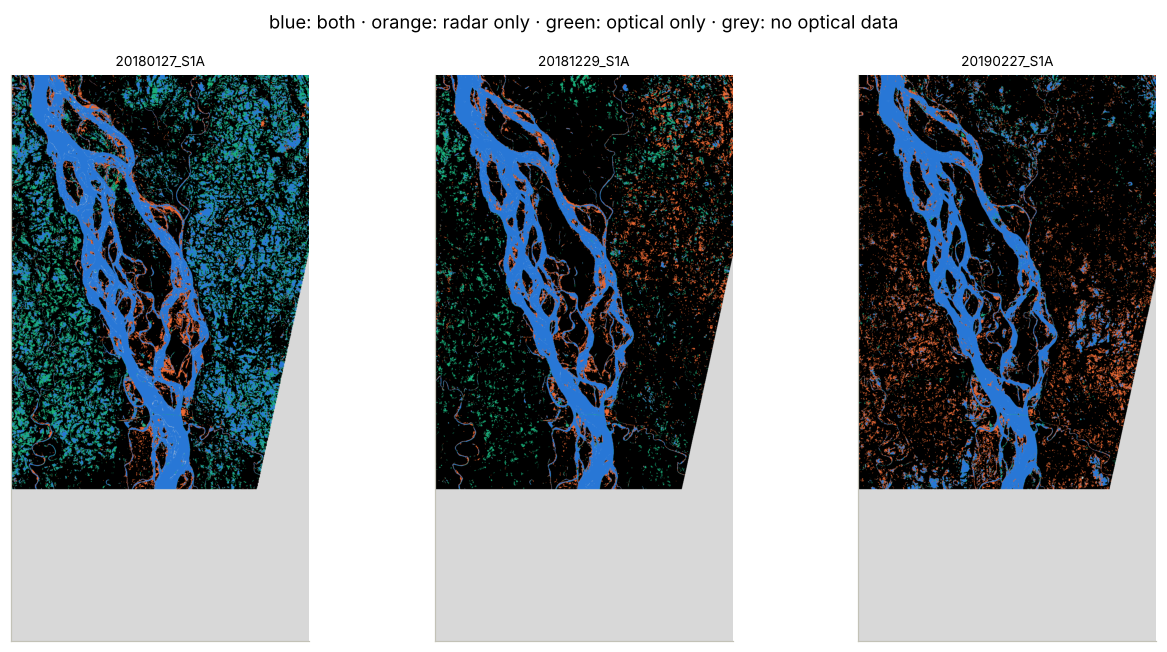

In [5]:
thumbs = sorted((M / "mask_pairs").glob("*.npz"))[:3]
if thumbs:
    fig, axes = plt.subplots(1, len(thumbs), figsize=(4 * len(thumbs), 6))
    for ax, f in zip(np.atleast_1d(axes), thumbs):
        z = np.load(f); s1, s2 = z["s1"], z["s2_channel"]
        img = np.zeros(s1.shape + (3,)); img[(s1 == 1) & (s2 == 1)] = [0.16, 0.47, 0.84]
        img[(s1 == 1) & (s2 == 0)] = [0.92, 0.41, 0.2]; img[(s1 == 0) & (s2 == 1)] = [0.1, 0.69, 0.48]
        img[s2 == 255] = 0.85
        ax.imshow(img); ax.set_title(f.stem.split("__")[0], fontsize=9); ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle("blue: both · orange: radar only · green: optical only · grey: no optical data")
    plt.tight_layout(); plt.show()
else:
    print("thumbnails are regenerated by python -m src.masks.validate_masks")